# CS677- Spring 2025 CRN#22550 Machine Learning – Final Project

# 1. Select Problem Statement and Dataset

# Dataset
# Bank Marketing

The data is related with direct marketing campaigns of a Portuguese banking institution. The marketing campaigns were based on phone calls. Often, more than one contact to the same client was required.

# Problem Statement
This project analyzes data from direct phone-based marketing campaigns conducted by a Portuguese banking institution.
The objective is to predict whether a client will subscribe to a term deposit (y) based on various features such as demographic details, financial status, previous campaign outcomes, and especially the duration of the last call, which plays a critical role in client conversion.
By developing a binary classification model, the goal is to help the bank target the right clients, reduce unnecessary follow-ups, and maximize campaign efficiency.

# 2. Perform Exploratory Data Analysis (EDA)

## STEP 1: Import Libraries

In [1]:
# Step 1: Import Libraries

# Basic Data Handling
import pandas as pd
import numpy as np

# Data Visualization
import matplotlib.pyplot as plt
import seaborn as sns

# Preprocessing
from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.model_selection import train_test_split, GridSearchCV, StratifiedKFold
from sklearn.impute import SimpleImputer

# Machine Learning Models
from sklearn.linear_model import LogisticRegression
from sklearn.naive_bayes import GaussianNB
from sklearn.neighbors import KNeighborsClassifier
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
from xgboost import XGBClassifier


# Evaluation Metrics
from sklearn.metrics import classification_report, confusion_matrix, ConfusionMatrixDisplay, accuracy_score, precision_score, recall_score, f1_score, roc_curve, auc

# Suppress warnings
import warnings
warnings.filterwarnings('ignore')


In [2]:
data = pd.read_csv('bank-additional-full.csv', sep=';')
# Structure of the dataset
data.head(), data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 41188 entries, 0 to 41187
Data columns (total 21 columns):
 #   Column          Non-Null Count  Dtype  
---  ------          --------------  -----  
 0   age             41188 non-null  int64  
 1   job             41188 non-null  object 
 2   marital         41188 non-null  object 
 3   education       41188 non-null  object 
 4   default         41188 non-null  object 
 5   housing         41188 non-null  object 
 6   loan            41188 non-null  object 
 7   contact         41188 non-null  object 
 8   month           41188 non-null  object 
 9   day_of_week     41188 non-null  object 
 10  duration        41188 non-null  int64  
 11  campaign        41188 non-null  int64  
 12  pdays           41188 non-null  int64  
 13  previous        41188 non-null  int64  
 14  poutcome        41188 non-null  object 
 15  emp.var.rate    41188 non-null  float64
 16  cons.price.idx  41188 non-null  float64
 17  cons.conf.idx   41188 non-null 

(   age        job  marital    education  default housing loan    contact  \
 0   56  housemaid  married     basic.4y       no      no   no  telephone   
 1   57   services  married  high.school  unknown      no   no  telephone   
 2   37   services  married  high.school       no     yes   no  telephone   
 3   40     admin.  married     basic.6y       no      no   no  telephone   
 4   56   services  married  high.school       no      no  yes  telephone   
 
   month day_of_week  ...  campaign  pdays  previous     poutcome emp.var.rate  \
 0   may         mon  ...         1    999         0  nonexistent          1.1   
 1   may         mon  ...         1    999         0  nonexistent          1.1   
 2   may         mon  ...         1    999         0  nonexistent          1.1   
 3   may         mon  ...         1    999         0  nonexistent          1.1   
 4   may         mon  ...         1    999         0  nonexistent          1.1   
 
    cons.price.idx  cons.conf.idx  euribor

In [5]:
data.shape

(41188, 21)

In [7]:
data.isnull().sum()

age               0
job               0
marital           0
education         0
default           0
housing           0
loan              0
contact           0
month             0
day_of_week       0
duration          0
campaign          0
pdays             0
previous          0
poutcome          0
emp.var.rate      0
cons.price.idx    0
cons.conf.idx     0
euribor3m         0
nr.employed       0
y                 0
dtype: int64

## One Hot Encoding

In [12]:
# Converting categorical variables to dummy/indicator variables
data = pd.get_dummies(data, drop_first=True)
data.head(), data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 41188 entries, 0 to 41187
Data columns (total 54 columns):
 #   Column                         Non-Null Count  Dtype  
---  ------                         --------------  -----  
 0   age                            41188 non-null  int64  
 1   duration                       41188 non-null  int64  
 2   campaign                       41188 non-null  int64  
 3   pdays                          41188 non-null  int64  
 4   previous                       41188 non-null  int64  
 5   emp.var.rate                   41188 non-null  float64
 6   cons.price.idx                 41188 non-null  float64
 7   cons.conf.idx                  41188 non-null  float64
 8   euribor3m                      41188 non-null  float64
 9   nr.employed                    41188 non-null  float64
 10  job_blue-collar                41188 non-null  bool   
 11  job_entrepreneur               41188 non-null  bool   
 12  job_housemaid                  41188 non-null 

(   age  duration  campaign  pdays  previous  emp.var.rate  cons.price.idx  \
 0   56       261         1    999         0           1.1          93.994   
 1   57       149         1    999         0           1.1          93.994   
 2   37       226         1    999         0           1.1          93.994   
 3   40       151         1    999         0           1.1          93.994   
 4   56       307         1    999         0           1.1          93.994   
 
    cons.conf.idx  euribor3m  nr.employed  ...  month_nov  month_oct  \
 0          -36.4      4.857       5191.0  ...      False      False   
 1          -36.4      4.857       5191.0  ...      False      False   
 2          -36.4      4.857       5191.0  ...      False      False   
 3          -36.4      4.857       5191.0  ...      False      False   
 4          -36.4      4.857       5191.0  ...      False      False   
 
    month_sep  day_of_week_mon  day_of_week_thu  day_of_week_tue  \
 0      False             Tr

In [14]:
data["y_yes"].value_counts()

y_yes
False    36548
True      4640
Name: count, dtype: int64

In [16]:
# Define features (X) and target (y)
X = data.drop('y_yes', axis=1)
y = data['y_yes']


# EDA

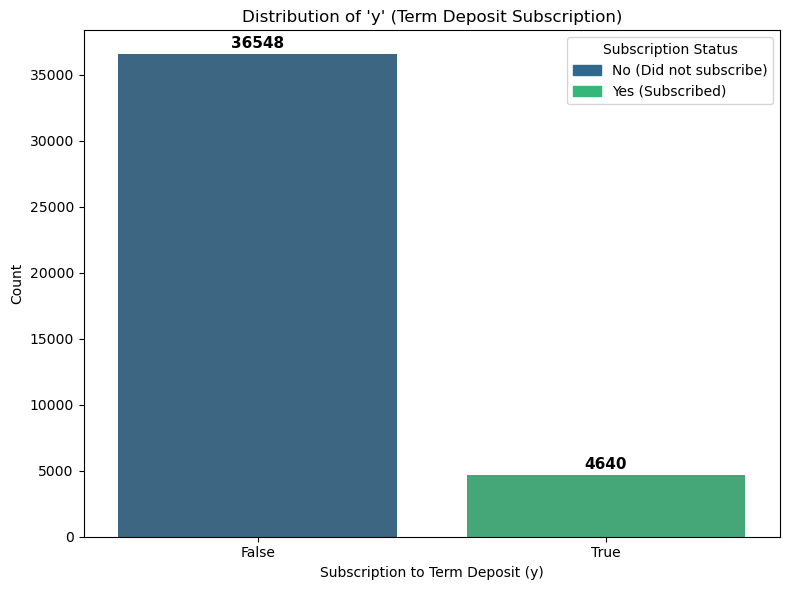

In [19]:
plt.figure(figsize=(8, 6))
ax = sns.countplot(data=data, x='y_yes', palette='viridis')

# Add value labels on top of bars
for p in ax.patches:
    count = int(p.get_height())
    ax.text(p.get_x() + p.get_width() / 2., p.get_height() + 500,
            f'{count}', ha='center', fontsize=11, weight='bold')

# Custom legend
legend_labels = ['No (Did not subscribe)', 'Yes (Subscribed)']
handles = [plt.Rectangle((0,0),1,1, color=col) for col in sns.color_palette('viridis', 2)]
plt.legend(handles, legend_labels, title='Subscription Status')

plt.title("Distribution of 'y' (Term Deposit Subscription)")
plt.xlabel("Subscription to Term Deposit (y)")
plt.ylabel("Count")
plt.tight_layout()
plt.show()

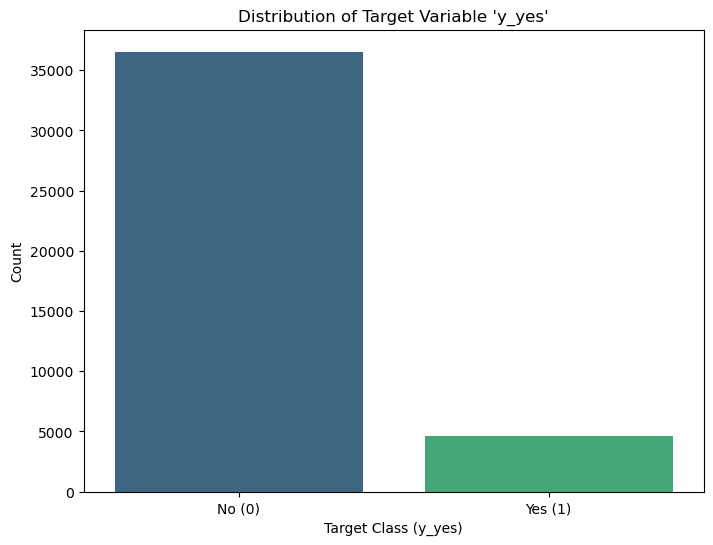

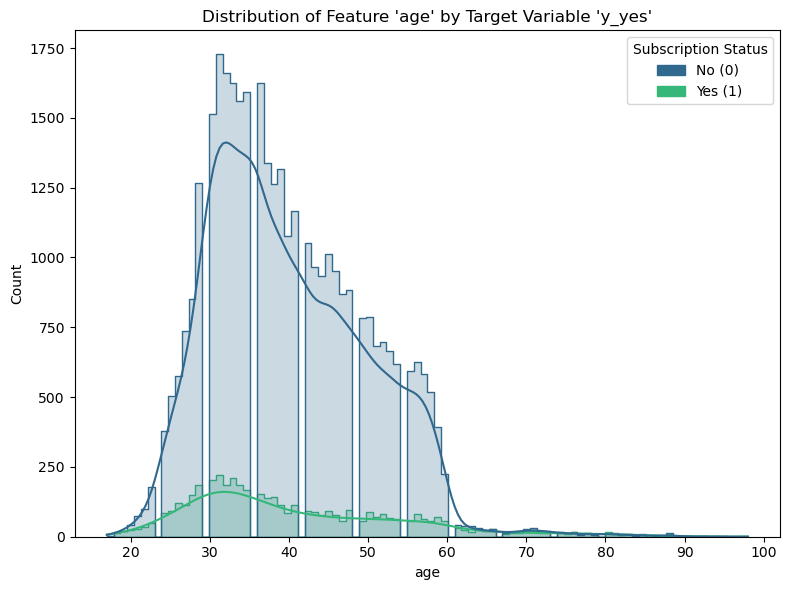

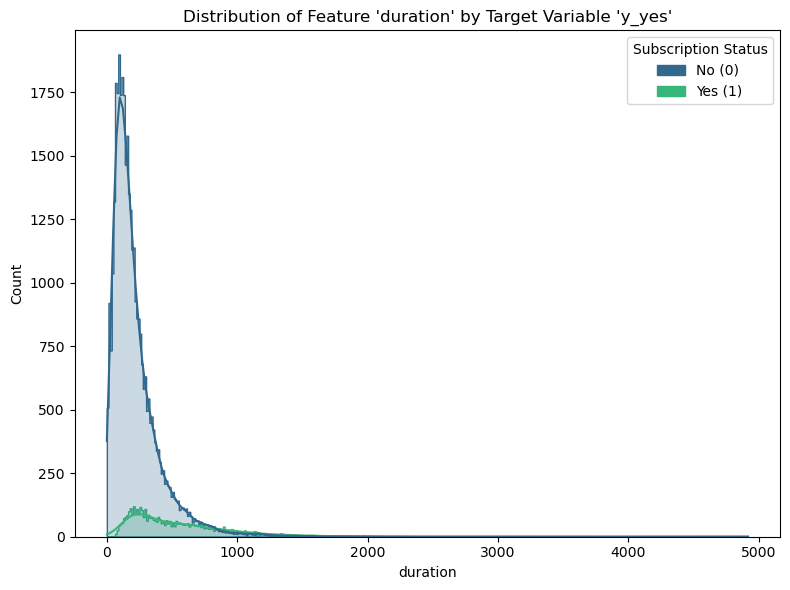

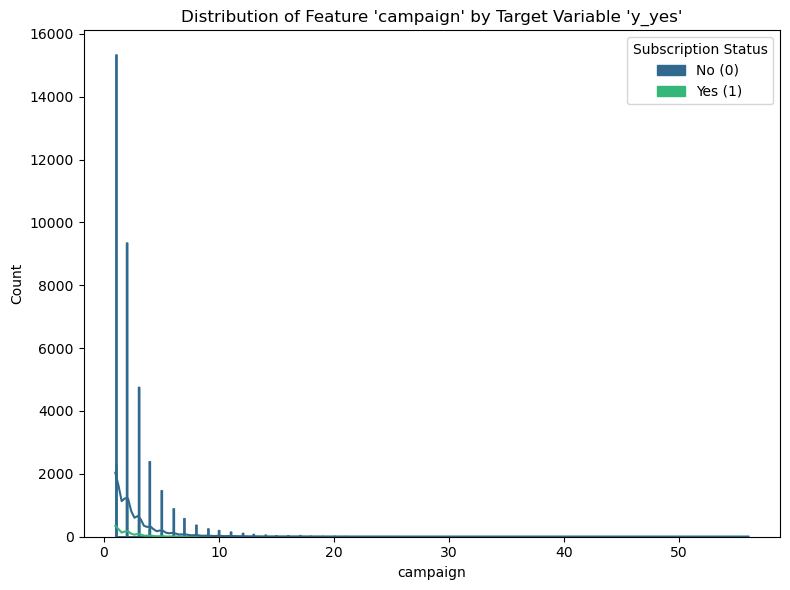

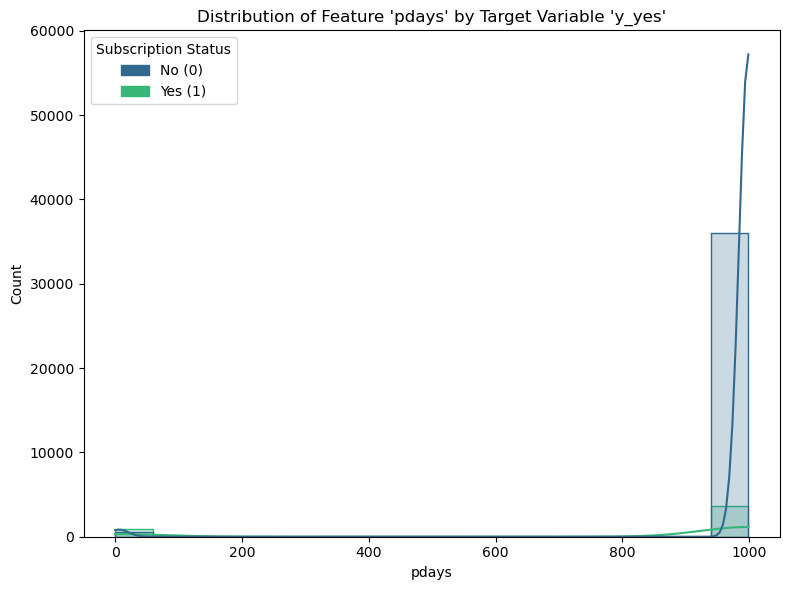

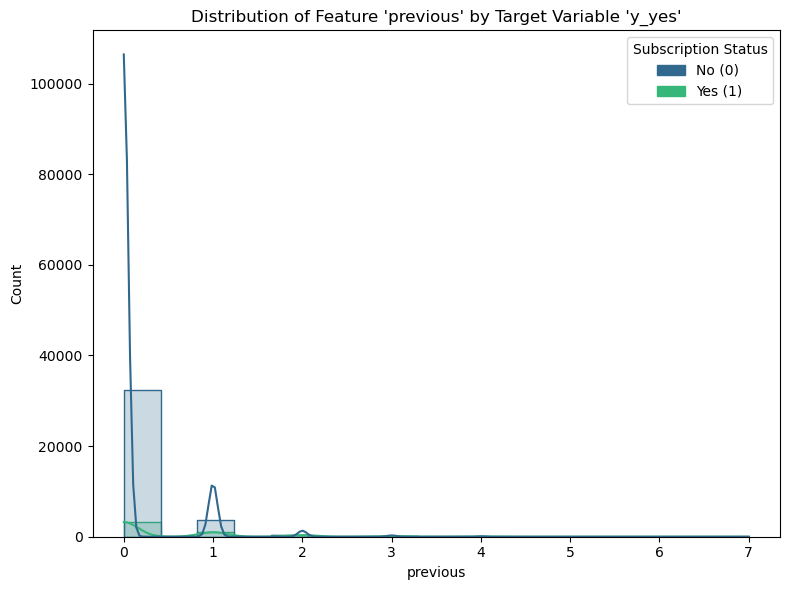

In [25]:

# Countplot for target distribution
plt.figure(figsize=(8, 6))
sns.countplot(x=y, palette='viridis')
plt.title("Distribution of Target Variable 'y_yes'")
plt.xlabel("Target Class (y_yes)")
plt.ylabel("Count")
plt.xticks([0, 1], ['No (0)', 'Yes (1)'])
plt.show()

# Plot histograms for sample features
sample_features = X.columns[:5]

for feature in sample_features:
    plt.figure(figsize=(8, 6))
    ax = sns.histplot(data=X, x=feature, hue=y, kde=True, palette='viridis', element="step")

    plt.title(f"Distribution of Feature '{feature}' by Target Variable 'y_yes'")
    plt.xlabel(feature)
    plt.ylabel("Count")
    
    # Custom legend labels
    handles = [plt.Rectangle((0, 0), 1, 1, color=color) for color in sns.color_palette("viridis", 2)]
    labels = ['No (0)', 'Yes (1)']
    plt.legend(handles, labels, title="Subscription Status")
    
    plt.tight_layout()
    plt.show()


## Outliers checking

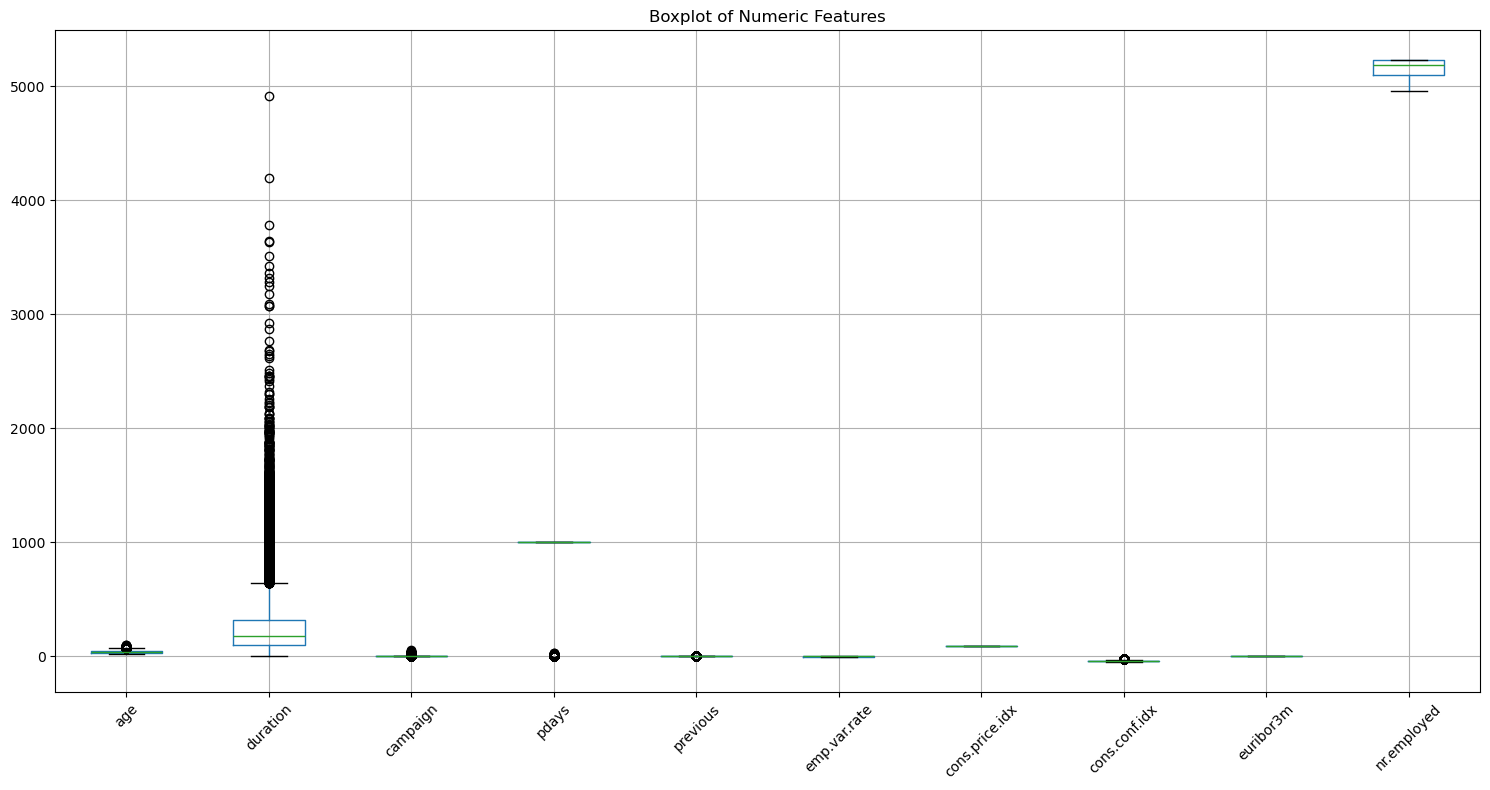

In [28]:
# Select only numeric columns
numeric_cols = X.select_dtypes(include=['int64', 'float64']).columns


# Boxplots for all numeric columns
plt.figure(figsize=(15, 8))
X[numeric_cols].boxplot(rot=45)
plt.title("Boxplot of Numeric Features")
plt.tight_layout()
plt.show()


## Detect Outliers Using IQR Method

In [31]:
# Create a copy to modify
X_outlier_checked = X.copy()

for col in numeric_cols:
    Q1 = X_outlier_checked[col].quantile(0.25)
    Q3 = X_outlier_checked[col].quantile(0.75)
    IQR = Q3 - Q1
    lower_bound = Q1 - 1.5 * IQR
    upper_bound = Q3 + 1.5 * IQR

    # Option 1: Remove outliers
    # X_outlier_checked = X_outlier_checked[(X_outlier_checked[col] >= lower_bound) & (X_outlier_checked[col] <= upper_bound)]

    # Option 2: Cap outliers (recommended for this case)
    X_outlier_checked[col] = np.where(X_outlier_checked[col] < lower_bound, lower_bound,
                             np.where(X_outlier_checked[col] > upper_bound, upper_bound, X_outlier_checked[col]))


## After Outlier Handling (IQR Capped)

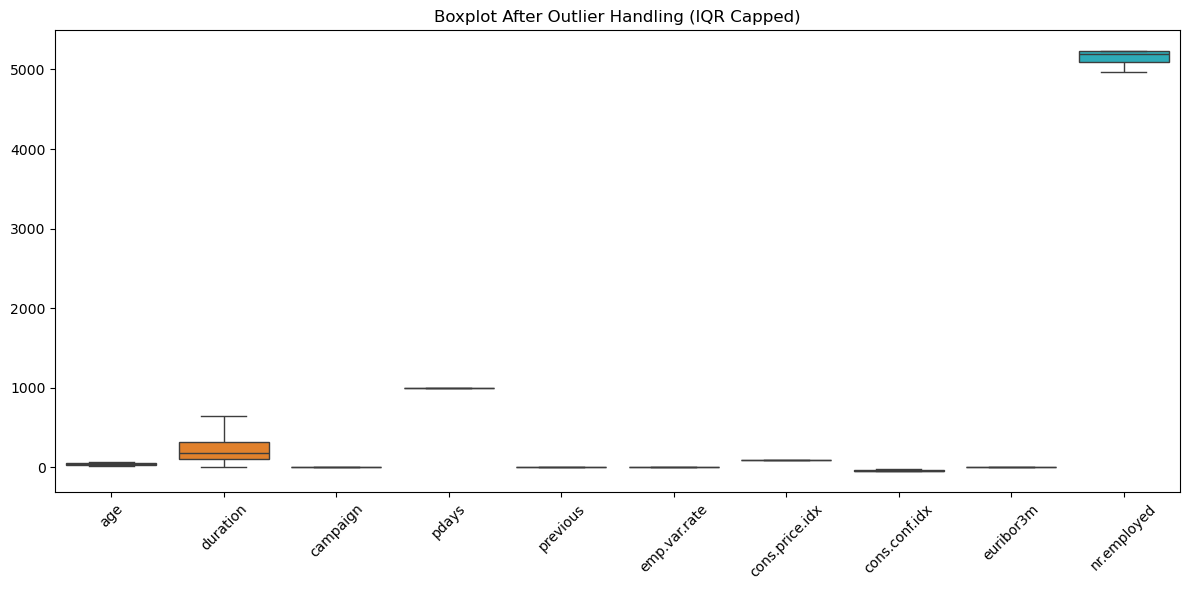

In [34]:
import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize=(12, 6))
sns.boxplot(data=X_outlier_checked[numeric_cols])
plt.title("Boxplot After Outlier Handling (IQR Capped)")
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()


## feature importances

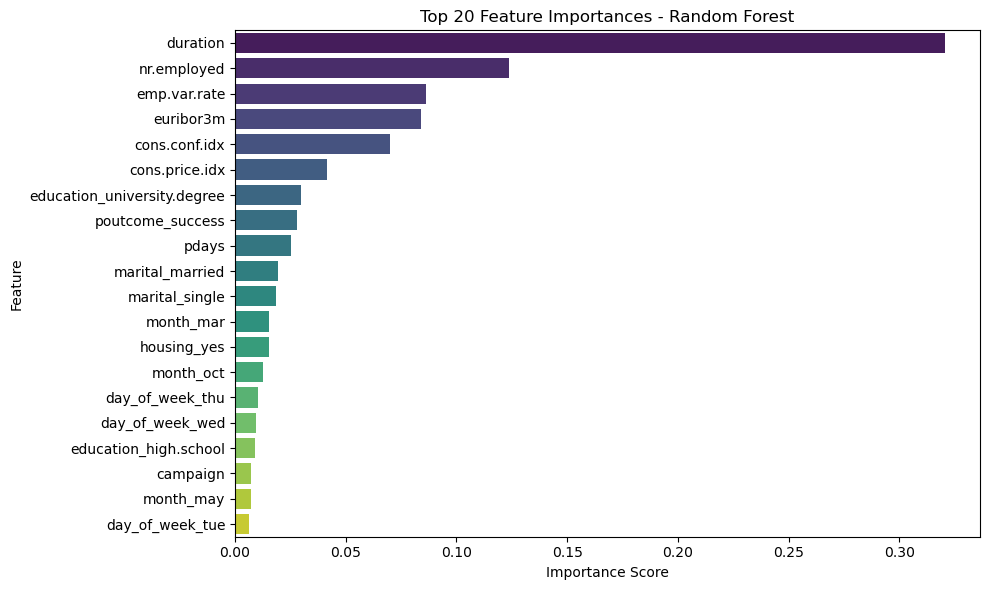

In [78]:
# Get feature importances from the trained Random Forest model
rf_importances = rf_model.feature_importances_

# Map to feature names
feature_names = X.columns
rf_feat_df = pd.DataFrame({
    'Feature': feature_names,
    'Importance': rf_importances
}).sort_values(by='Importance', ascending=False)

# Plot top 20 features
plt.figure(figsize=(10, 6))
sns.barplot(x='Importance', y='Feature', data=rf_feat_df.head(20), palette='viridis')
plt.title('Top 20 Feature Importances - Random Forest')
plt.xlabel('Importance Score')
plt.ylabel('Feature')
plt.tight_layout()
plt.show()


## Oversampling

In [40]:
from imblearn.over_sampling import SMOTE

# Separate features and target
X = data.drop('y_yes', axis=1)
y = data['y_yes']

# Apply SMOTE
smote = SMOTE(random_state=42)
X_balanced, y_balanced = smote.fit_resample(X, y)

# Check new balance
print(y_balanced.value_counts())


y_yes
False    36548
True     36548
Name: count, dtype: int64


#### Distribution of Age

Clients aged 30–40 are the most likely to subscribe.


#### Distribution of Duration

Longer calls have more subscribers:
As duration increases (400–1000 seconds), the green line (y_yes = True) becomes more visible
This suggests clients who subscribed tend to have longer conversations


#### Distribution of campaign

Subscription chances decrease with more contacts:
The green (True) bar is relatively strong for 1–2 calls, after 4+ contacts, subscription rates become nearly zero


#### Distribution of Pdays

Smaller pdays values (left side):
Clients recently contacted (pdays < 100) show a higher rate of subscription (more green compared to blue).
Suggests recency of contact has some positive influence on conversion.

# 2- Splitting the dataset into training and test datasets at a 70%/30% ratio

In [44]:
# 1. Split the balanced data into training and testing sets
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler

X_train, X_test, y_train, y_test = train_test_split(
    X_balanced, y_balanced, 
    test_size=0.3, 
    random_state=42, 
    stratify=y_balanced
)

# Print shapes of the datasets
print(f"Shape of X_train: {X_train.shape}")
print(f"Shape of X_test: {X_test.shape}")
print(f"Shape of y_train: {y_train.shape}")
print(f"Shape of y_test: {y_test.shape}")

# 2. Feature scaling (after split)
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)


Shape of X_train: (51167, 53)
Shape of X_test: (21929, 53)
Shape of y_train: (51167,)
Shape of y_test: (21929,)


In [46]:
# 1. Logistic Regression
lr_model = LogisticRegression(random_state=42)
lr_model.fit(X_train_scaled, y_train)

# 2. Naive Bayes
nb_model = GaussianNB()
nb_model.fit(X_train_scaled, y_train)

# 3. K-Nearest Neighbors
knn_model = KNeighborsClassifier(n_neighbors=5)  # Default 5 neighbors
knn_model.fit(X_train_scaled, y_train)

# 4. Decision Tree (overfitting controlled)
dt_model = DecisionTreeClassifier(
    max_depth=5,
    min_samples_split=10,
    min_samples_leaf=5,
    random_state=42
)
dt_model.fit(X_train_scaled, y_train)

# 5. Random Forest (overfitting controlled)
rf_model = RandomForestClassifier(
    n_estimators=100,
    max_depth=7,
    min_samples_split=10,
    min_samples_leaf=5,
    max_features='sqrt',
    random_state=42
)
rf_model.fit(X_train_scaled, y_train)

# 6. XGBoost (overfitting controlled)
xgb_model = XGBClassifier(
    use_label_encoder=False,
    eval_metric='logloss',
    max_depth=5,
    learning_rate=0.1,
    n_estimators=100,
    subsample=0.8,
    colsample_bytree=0.8,
    gamma=1,
    reg_alpha=0.5,
    reg_lambda=1.0,
    random_state=42
)
xgb_model.fit(X_train_scaled, y_train)

XGBClassifier(base_score=None, booster=None, callbacks=None,
              colsample_bylevel=None, colsample_bynode=None,
              colsample_bytree=0.8, device=None, early_stopping_rounds=None,
              enable_categorical=False, eval_metric='logloss',
              feature_types=None, feature_weights=None, gamma=1,
              grow_policy=None, importance_type=None,
              interaction_constraints=None, learning_rate=0.1, max_bin=None,
              max_cat_threshold=None, max_cat_to_onehot=None,
              max_delta_step=None, max_depth=5, max_leaves=None,
              min_child_weight=None, missing=nan, monotone_constraints=None,
              multi_strategy=None, n_estimators=100, n_jobs=None,
              num_parallel_tree=None, ...)

## Using an Optimizer

### 1. Manual Logistic Regression with Batch Gradient Descent

In [50]:
import numpy as np

# Sigmoid activation function
def sigmoid(z):
    return 1 / (1 + np.exp(-z))

# Binary cross-entropy loss
def compute_loss(y, y_pred):
    eps = 1e-15
    y_pred = np.clip(y_pred, eps, 1 - eps)
    return -np.mean(y * np.log(y_pred) + (1 - y) * np.log(1 - y_pred))

# Gradient Descent implementation
def logistic_regression_gd(X, y, learning_rate=0.01, epochs=1000):
    m, n = X.shape
    weights = np.zeros(n)
    bias = 0
    loss_history = []

    for i in range(epochs):
        # Linear combination
        z = np.dot(X, weights) + bias
        y_pred = sigmoid(z)

        # Compute gradients
        dw = (1 / m) * np.dot(X.T, (y_pred - y))
        db = (1 / m) * np.sum(y_pred - y)

        # Update parameters
        weights -= learning_rate * dw
        bias -= learning_rate * db

        # Track loss
        if i % 100 == 0:
            loss = compute_loss(y, y_pred)
            loss_history.append(loss)
            print(f"Epoch {i}: Loss = {loss:.4f}")

    return weights, bias, loss_history

# Prepare data
X_np = np.array(X_train_scaled)
y_np = np.array(y_train)

# Train Logistic Regression with Gradient Descent
weights, bias, losses = logistic_regression_gd(X_np, y_np, learning_rate=0.1, epochs=1000)


Epoch 0: Loss = 0.6931
Epoch 100: Loss = 0.2447
Epoch 200: Loss = 0.2103
Epoch 300: Loss = 0.1976
Epoch 400: Loss = 0.1912
Epoch 500: Loss = 0.1874
Epoch 600: Loss = 0.1849
Epoch 700: Loss = 0.1832
Epoch 800: Loss = 0.1820
Epoch 900: Loss = 0.1811


### 2. XGBoost Model

In [53]:
from xgboost import XGBClassifier

# XGBoost uses gradient boosting to minimize loss
xgb_model = XGBClassifier(
    use_label_encoder=False,
    eval_metric='logloss',
    max_depth=5,
    learning_rate=0.1,
    n_estimators=100,
    subsample=0.8,
    colsample_bytree=0.8,
    gamma=1,
    reg_alpha=0.5,
    reg_lambda=1.0,
    random_state=42
)

# Train XGBoost
xgb_model.fit(X_train_scaled, y_train)


XGBClassifier(base_score=None, booster=None, callbacks=None,
              colsample_bylevel=None, colsample_bynode=None,
              colsample_bytree=0.8, device=None, early_stopping_rounds=None,
              enable_categorical=False, eval_metric='logloss',
              feature_types=None, feature_weights=None, gamma=1,
              grow_policy=None, importance_type=None,
              interaction_constraints=None, learning_rate=0.1, max_bin=None,
              max_cat_threshold=None, max_cat_to_onehot=None,
              max_delta_step=None, max_depth=5, max_leaves=None,
              min_child_weight=None, missing=nan, monotone_constraints=None,
              multi_strategy=None, n_estimators=100, n_jobs=None,
              num_parallel_tree=None, ...)

# Step-4 Evaluate Model Performance

## Stratified K-Fold Cross-Validation on All Models

In [57]:
from sklearn.model_selection import StratifiedKFold, cross_val_score
import numpy as np

# Create dictionary of models
models = {
    'Logistic Regression': LogisticRegression(random_state=42),
    'Naive Bayes': GaussianNB(),
    'K-Nearest Neighbors': KNeighborsClassifier(n_neighbors=5),
    'Decision Tree': DecisionTreeClassifier(random_state=42),
    'Random Forest': RandomForestClassifier(n_estimators=100, random_state=42),
    'XGBoost': XGBClassifier(use_label_encoder=False, eval_metric='logloss', random_state=42)
}

# Initialize Stratified K-Fold
strat_kfold = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

# Dictionary to store cross-validation results
cv_results = {}

# Perform Cross-Validation for each model
for name, model in models.items():
    scores = cross_val_score(model, X_train_scaled, y_train, cv=strat_kfold, scoring='accuracy')
    cv_results[name] = {
        'Mean Accuracy': np.round(scores.mean(), 4),
        'Standard Deviation': np.round(scores.std(), 4)
    }
    print(f"=== {name} ===")
    print("Cross-Validation Scores:", np.round(scores, 4))
    print("Mean Accuracy:", np.round(scores.mean(), 4))
    print("Standard Deviation:", np.round(scores.std(), 4))
    print("="*60)

# Optional: Create a nice table view
import pandas as pd
cv_results_df = pd.DataFrame(cv_results).T
display(cv_results_df)


=== Logistic Regression ===
Cross-Validation Scores: [0.9259 0.9387 0.9337 0.9294 0.9297]
Mean Accuracy: 0.9315
Standard Deviation: 0.0044
=== Naive Bayes ===
Cross-Validation Scores: [0.814  0.8167 0.8105 0.8059 0.8047]
Mean Accuracy: 0.8103
Standard Deviation: 0.0046
=== K-Nearest Neighbors ===
Cross-Validation Scores: [0.9065 0.9206 0.9145 0.9129 0.9114]
Mean Accuracy: 0.9132
Standard Deviation: 0.0046
=== Decision Tree ===
Cross-Validation Scores: [0.9259 0.9323 0.9221 0.9292 0.9319]
Mean Accuracy: 0.9283
Standard Deviation: 0.0038
=== Random Forest ===
Cross-Validation Scores: [0.9482 0.9561 0.9515 0.9529 0.952 ]
Mean Accuracy: 0.9522
Standard Deviation: 0.0025
=== XGBoost ===
Cross-Validation Scores: [0.9458 0.9526 0.949  0.9495 0.95  ]
Mean Accuracy: 0.9494
Standard Deviation: 0.0022


,Mean Accuracy,Standard Deviation
Logistic Regression,0.9315,0.0044
Naive Bayes,0.8103,0.0046
K-Nearest Neighbors,0.9132,0.0046
Decision Tree,0.9283,0.0038
Random Forest,0.9522,0.0025
XGBoost,0.9494,0.0022


## Confusion Matrix Plot Function

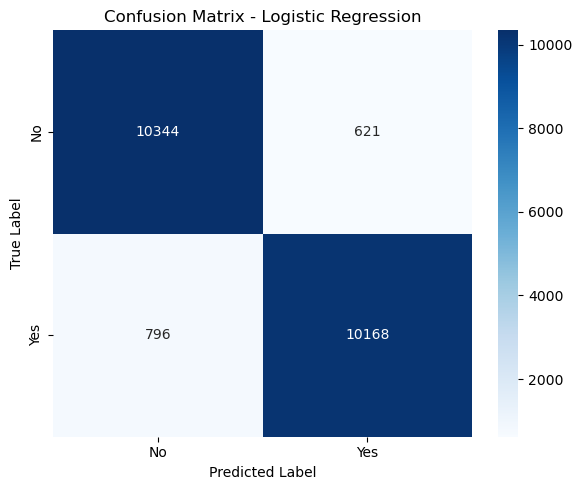

Classification Report - Logistic Regression:

              precision    recall  f1-score   support

          No       0.93      0.94      0.94     10965
         Yes       0.94      0.93      0.93     10964

    accuracy                           0.94     21929
   macro avg       0.94      0.94      0.94     21929
weighted avg       0.94      0.94      0.94     21929



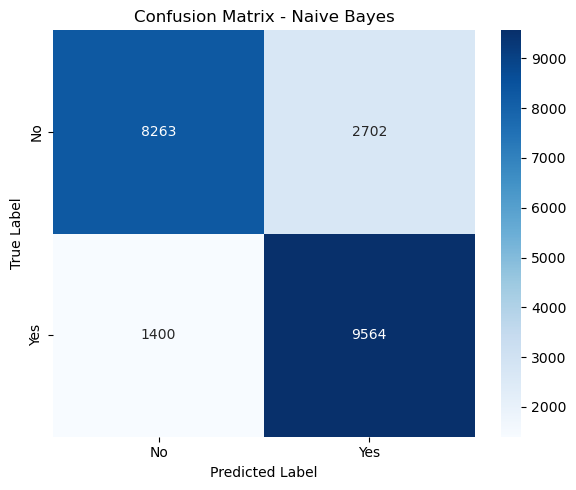

Classification Report - Naive Bayes:

              precision    recall  f1-score   support

          No       0.86      0.75      0.80     10965
         Yes       0.78      0.87      0.82     10964

    accuracy                           0.81     21929
   macro avg       0.82      0.81      0.81     21929
weighted avg       0.82      0.81      0.81     21929



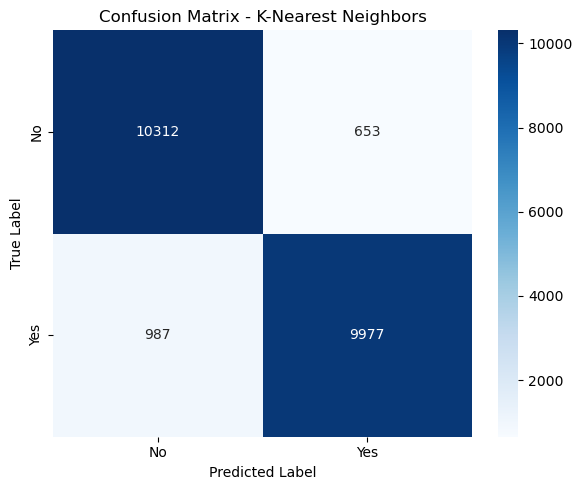

Classification Report - K-Nearest Neighbors:

              precision    recall  f1-score   support

          No       0.91      0.94      0.93     10965
         Yes       0.94      0.91      0.92     10964

    accuracy                           0.93     21929
   macro avg       0.93      0.93      0.93     21929
weighted avg       0.93      0.93      0.93     21929



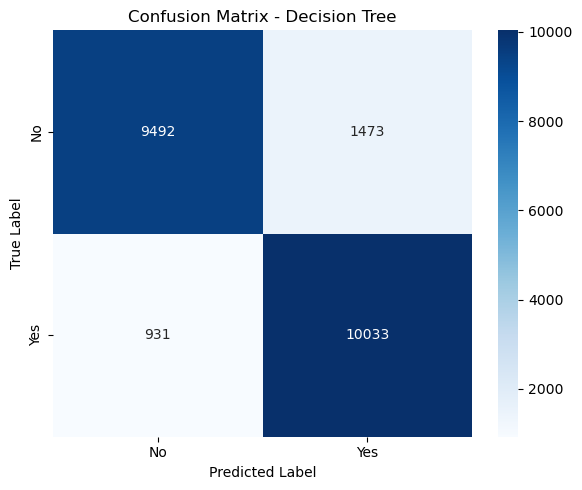

Classification Report - Decision Tree:

              precision    recall  f1-score   support

          No       0.91      0.87      0.89     10965
         Yes       0.87      0.92      0.89     10964

    accuracy                           0.89     21929
   macro avg       0.89      0.89      0.89     21929
weighted avg       0.89      0.89      0.89     21929



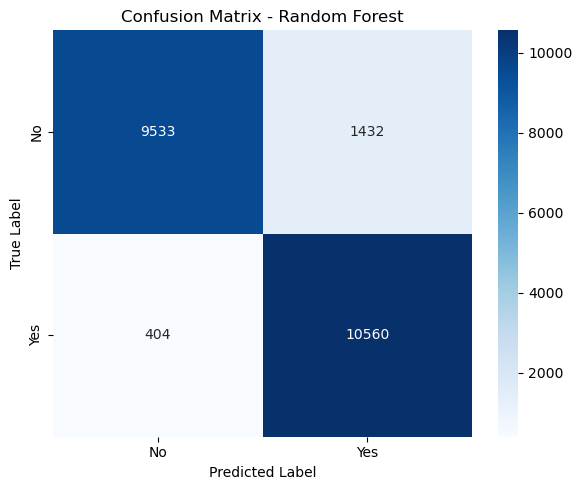

Classification Report - Random Forest:

              precision    recall  f1-score   support

          No       0.96      0.87      0.91     10965
         Yes       0.88      0.96      0.92     10964

    accuracy                           0.92     21929
   macro avg       0.92      0.92      0.92     21929
weighted avg       0.92      0.92      0.92     21929



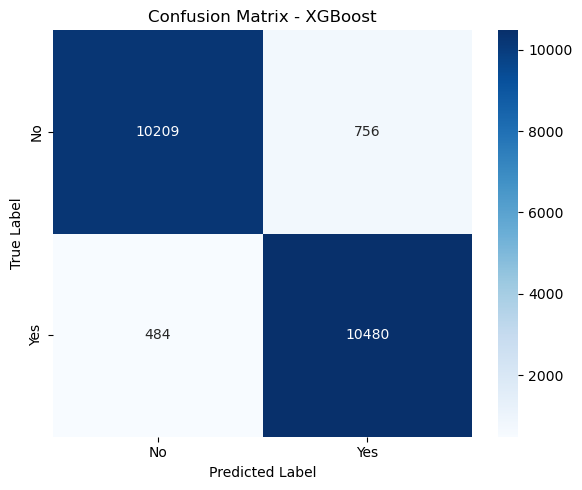

Classification Report - XGBoost:

              precision    recall  f1-score   support

          No       0.95      0.93      0.94     10965
         Yes       0.93      0.96      0.94     10964

    accuracy                           0.94     21929
   macro avg       0.94      0.94      0.94     21929
weighted avg       0.94      0.94      0.94     21929



In [60]:
def plot_confusion_matrix_with_report(y_true, y_pred, title):
    cm = confusion_matrix(y_true, y_pred)
    report = classification_report(y_true, y_pred, target_names=['No', 'Yes'])

    # Plot confusion matrix
    plt.figure(figsize=(6, 5))
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
                xticklabels=['No', 'Yes'], yticklabels=['No', 'Yes'])
    plt.xlabel('Predicted Label')
    plt.ylabel('True Label')
    plt.title(f'Confusion Matrix - {title}')
    plt.tight_layout()
    plt.show()

    # Print classification report
    print(f"Classification Report - {title}:\n")
    print(report)
    print("=" * 60)
# Logistic Regression
y_pred_lr = lr_model.predict(X_test_scaled)
plot_confusion_matrix_with_report(y_test, y_pred_lr, title='Logistic Regression')

# Naive Bayes
y_pred_nb = nb_model.predict(X_test_scaled)
plot_confusion_matrix_with_report(y_test, y_pred_nb, title='Naive Bayes')

# K-Nearest Neighbors
y_pred_knn = knn_model.predict(X_test_scaled)
plot_confusion_matrix_with_report(y_test, y_pred_knn, title='K-Nearest Neighbors')

# Decision Tree
y_pred_dt = dt_model.predict(X_test_scaled)
plot_confusion_matrix_with_report(y_test, y_pred_dt, title='Decision Tree')

# Random Forest
y_pred_rf = rf_model.predict(X_test_scaled)
plot_confusion_matrix_with_report(y_test, y_pred_rf, title='Random Forest')

# XGBoost
y_pred_xgb = xgb_model.predict(X_test_scaled)
plot_confusion_matrix_with_report(y_test, y_pred_xgb, title='XGBoost')


## Check Overfitting and Underfitting

In [63]:
from sklearn.metrics import confusion_matrix

def evaluate_model_with_confusion(model, X_test, y_test, model_name):
    y_pred = model.predict(X_test)
    cm = confusion_matrix(y_test, y_pred)
    tn, fp, fn, tp = cm.ravel()
    
    print(f"=== {model_name} ===")
    print(f"Confusion Matrix:\n{cm}")
    print(f"True Positives: {tp}")
    print(f"True Negatives: {tn}")
    print(f"False Positives: {fp}")
    print(f"False Negatives: {fn}")
    
    # Simple rule-based conclusion
    if tp + tn > fp + fn and fp + fn < (tp + tn) * 0.2:
        print("Model is well generalized.")
    elif fp + fn >= tp + tn:
        print("Model may be underfitting.")
    elif fn > tp or fp > tn:
        print("Model may be overfitting.")
    else:
        print("Model performance is mixed.")
    
    print("=" * 60)

# Run for all models
evaluate_model_with_confusion(lr_model, X_test_scaled, y_test, "Logistic Regression")
evaluate_model_with_confusion(nb_model, X_test_scaled, y_test, "Naive Bayes")
evaluate_model_with_confusion(knn_model, X_test_scaled, y_test, "K-Nearest Neighbors")
evaluate_model_with_confusion(dt_model, X_test_scaled, y_test, "Decision Tree")
evaluate_model_with_confusion(rf_model, X_test_scaled, y_test, "Random Forest")
evaluate_model_with_confusion(xgb_model, X_test_scaled, y_test, "XGBoost")


=== Logistic Regression ===
Confusion Matrix:
[[10344   621]
 [  796 10168]]
True Positives: 10168
True Negatives: 10344
False Positives: 621
False Negatives: 796
Model is well generalized.
=== Naive Bayes ===
Confusion Matrix:
[[8263 2702]
 [1400 9564]]
True Positives: 9564
True Negatives: 8263
False Positives: 2702
False Negatives: 1400
Model performance is mixed.
=== K-Nearest Neighbors ===
Confusion Matrix:
[[10312   653]
 [  987  9977]]
True Positives: 9977
True Negatives: 10312
False Positives: 653
False Negatives: 987
Model is well generalized.
=== Decision Tree ===
Confusion Matrix:
[[ 9492  1473]
 [  931 10033]]
True Positives: 10033
True Negatives: 9492
False Positives: 1473
False Negatives: 931
Model is well generalized.
=== Random Forest ===
Confusion Matrix:
[[ 9533  1432]
 [  404 10560]]
True Positives: 10560
True Negatives: 9533
False Positives: 1432
False Negatives: 404
Model is well generalized.
=== XGBoost ===
Confusion Matrix:
[[10209   756]
 [  484 10480]]
True Posi

## Learning Curve

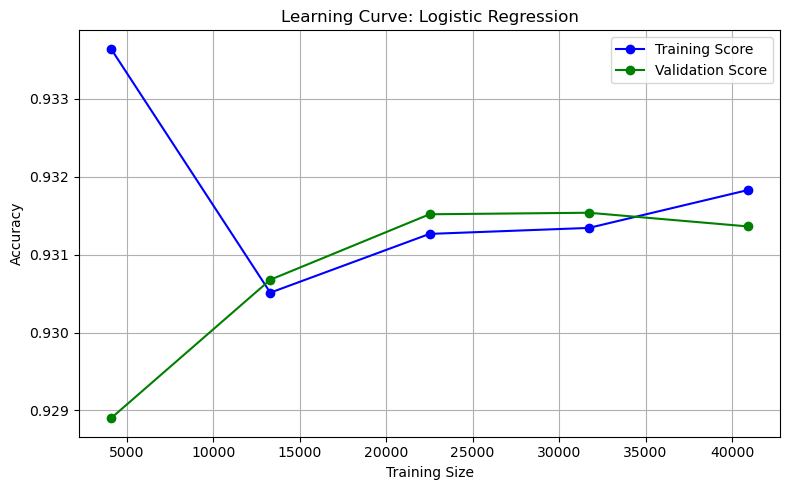

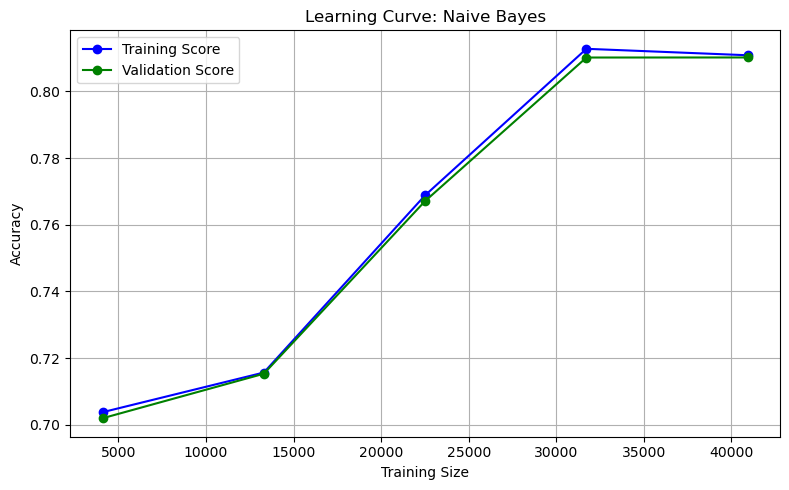

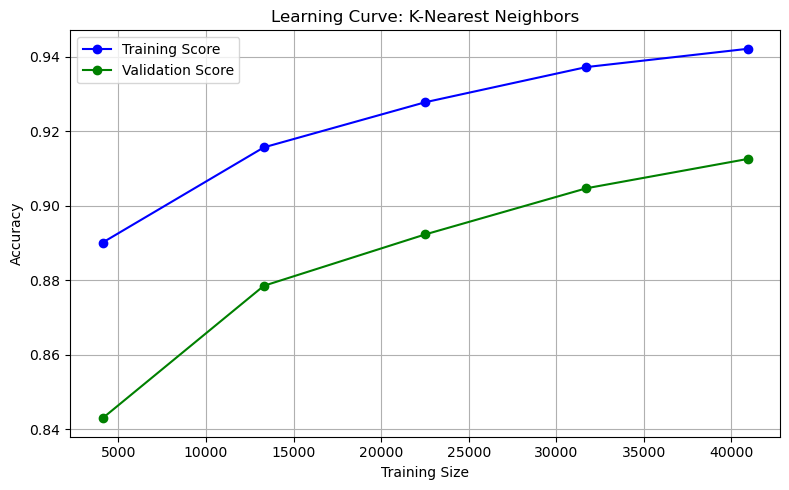

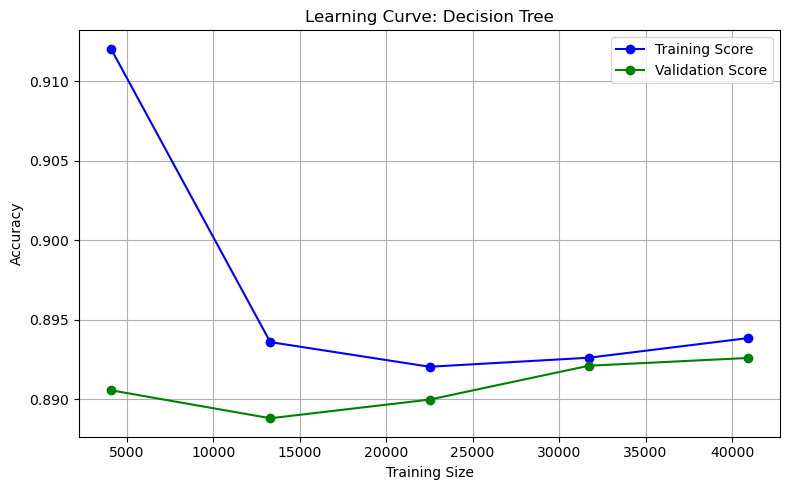

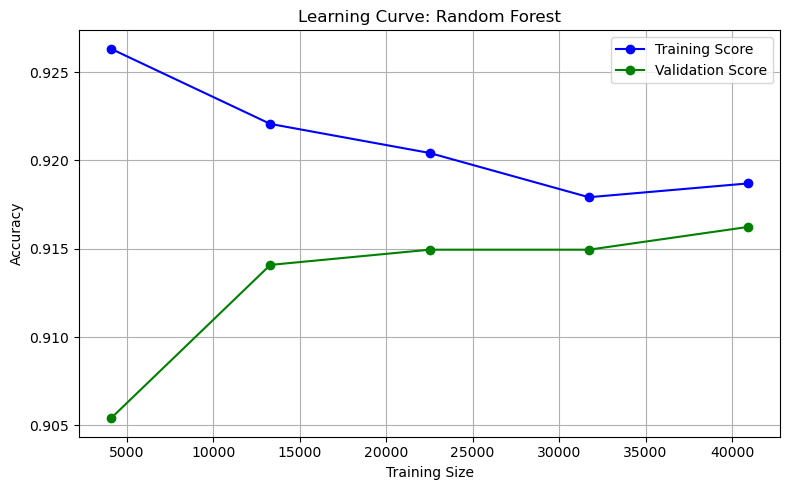

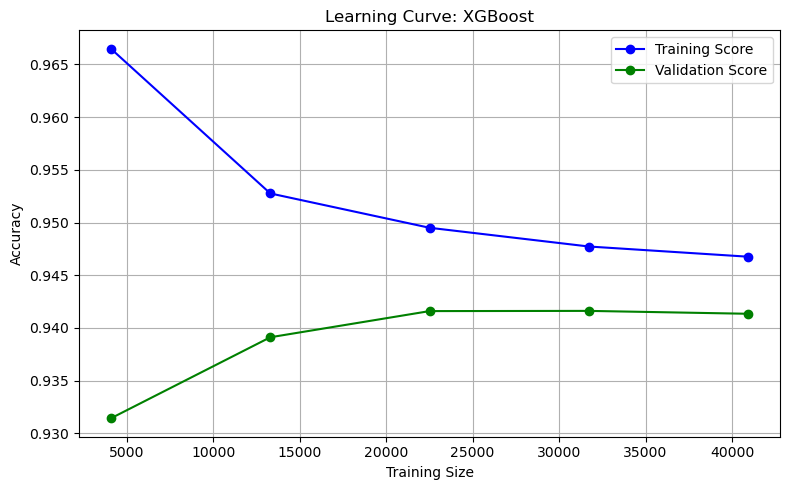

In [65]:
from sklearn.model_selection import learning_curve
import matplotlib.pyplot as plt
import numpy as np

def plot_learning_curve(estimator, X, y, title, cv=5, scoring='accuracy'):
    train_sizes, train_scores, val_scores = learning_curve(estimator, X, y, cv=cv, scoring=scoring, n_jobs=-1, train_sizes=np.linspace(0.1, 1.0, 5), random_state=42)
    
    train_scores_mean = train_scores.mean(axis=1)
    val_scores_mean = val_scores.mean(axis=1)
    
    plt.figure(figsize=(8, 5))
    plt.plot(train_sizes, train_scores_mean, 'o-', label='Training Score', color='blue')
    plt.plot(train_sizes, val_scores_mean, 'o-', label='Validation Score', color='green')
    plt.title(f'Learning Curve: {title}')
    plt.xlabel('Training Size')
    plt.ylabel('Accuracy')
    plt.grid(True)
    plt.legend(loc='best')
    plt.tight_layout()
    plt.show()
# Logistic Regression
plot_learning_curve(lr_model, X_train_scaled, y_train, title='Logistic Regression')

# Naive Bayes
plot_learning_curve(nb_model, X_train_scaled, y_train, title='Naive Bayes')

# K-Nearest Neighbors
plot_learning_curve(knn_model, X_train_scaled, y_train, title='K-Nearest Neighbors')

# Decision Tree
plot_learning_curve(dt_model, X_train_scaled, y_train, title='Decision Tree')

# Random Forest
plot_learning_curve(rf_model, X_train_scaled, y_train, title='Random Forest')

# XGBoost
plot_learning_curve(xgb_model, X_train_scaled, y_train, title='XGBoost')


## ROC and AUC Curves

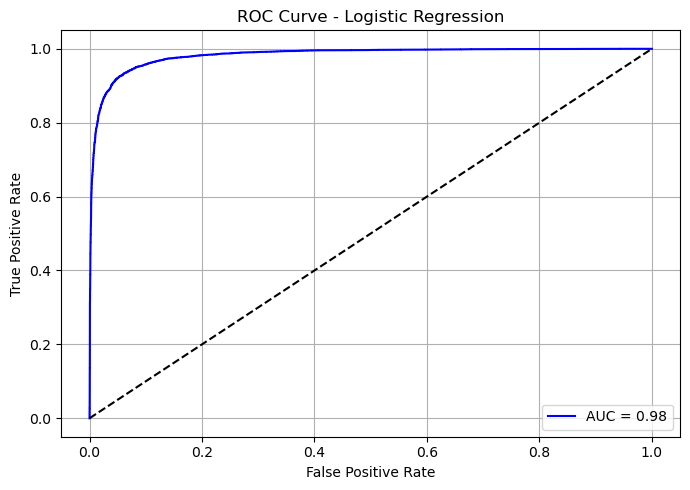

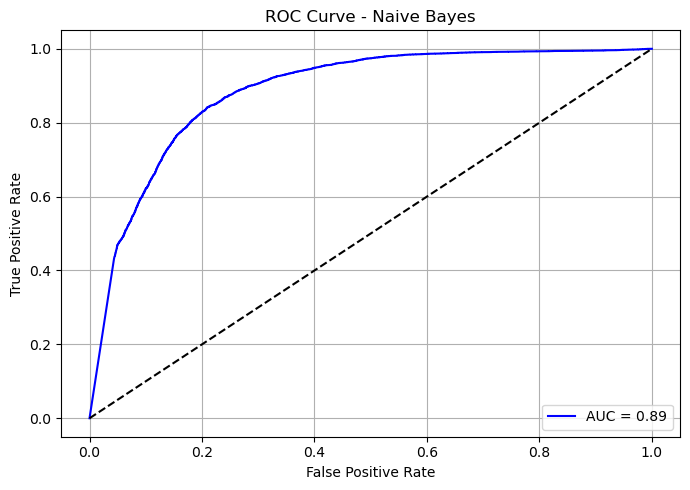

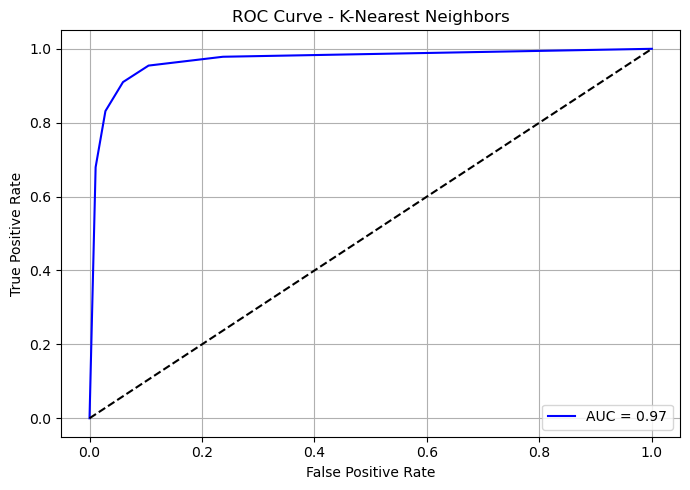

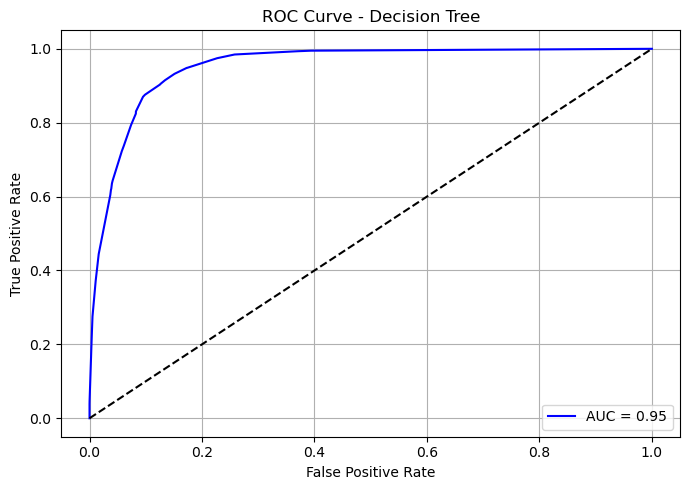

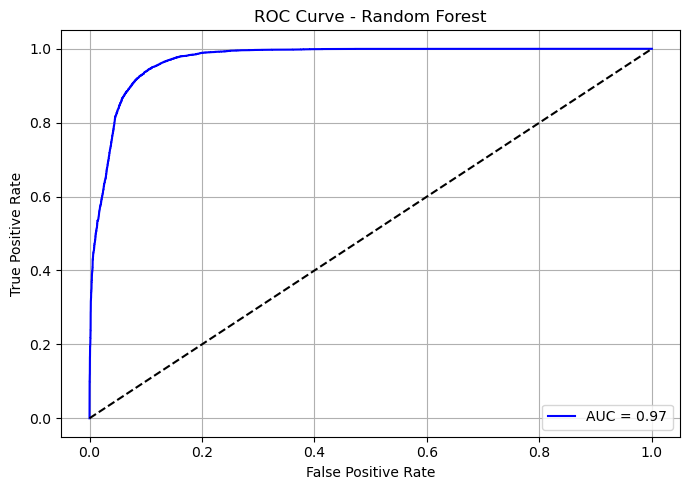

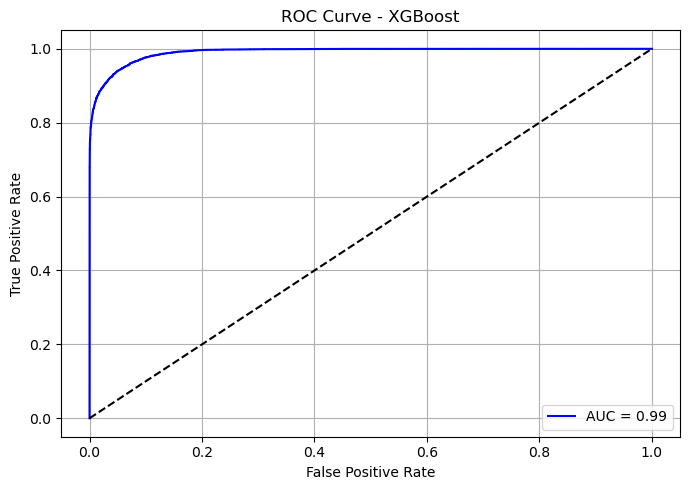

In [69]:
from sklearn.metrics import roc_curve, auc
import matplotlib.pyplot as plt

# Model dictionary
models = {
    'Logistic Regression': lr_model,
    'Naive Bayes': nb_model,
    'K-Nearest Neighbors': knn_model,
    'Decision Tree': dt_model,
    'Random Forest': rf_model,
    'XGBoost': xgb_model
}

# Plot individual ROC curve for each model
for name, model in models.items():
    # Get predicted probabilities (positive class)
    if hasattr(model, "predict_proba"):
        y_probs = model.predict_proba(X_test_scaled)[:, 1]
    else:
        y_probs = model.decision_function(X_test_scaled)

    # Compute ROC and AUC
    fpr, tpr, _ = roc_curve(y_test, y_probs)
    roc_auc = auc(fpr, tpr)

    # Plot
    plt.figure(figsize=(7, 5))
    plt.plot(fpr, tpr, label=f'AUC = {roc_auc:.2f}', color='blue')
    plt.plot([0, 1], [0, 1], 'k--')
    plt.title(f'ROC Curve - {name}')
    plt.xlabel('False Positive Rate')
    plt.ylabel('True Positive Rate')
    plt.legend(loc='lower right')
    plt.grid(True)
    plt.tight_layout()
    plt.show()


## Hyperparameter Tuning Comparision

,Model,F1 Score (Default),F1 Score (Tuned)
0,Logistic Regression,0.934860,0.935080
1,Naive Bayes,0.823418,0.823418
2,K-Nearest Neighbors,0.924053,0.916418
3,Decision Tree,0.934003,0.893013
4,Random Forest,0.955034,0.920021
5,XGBoost,0.951271,0.944144


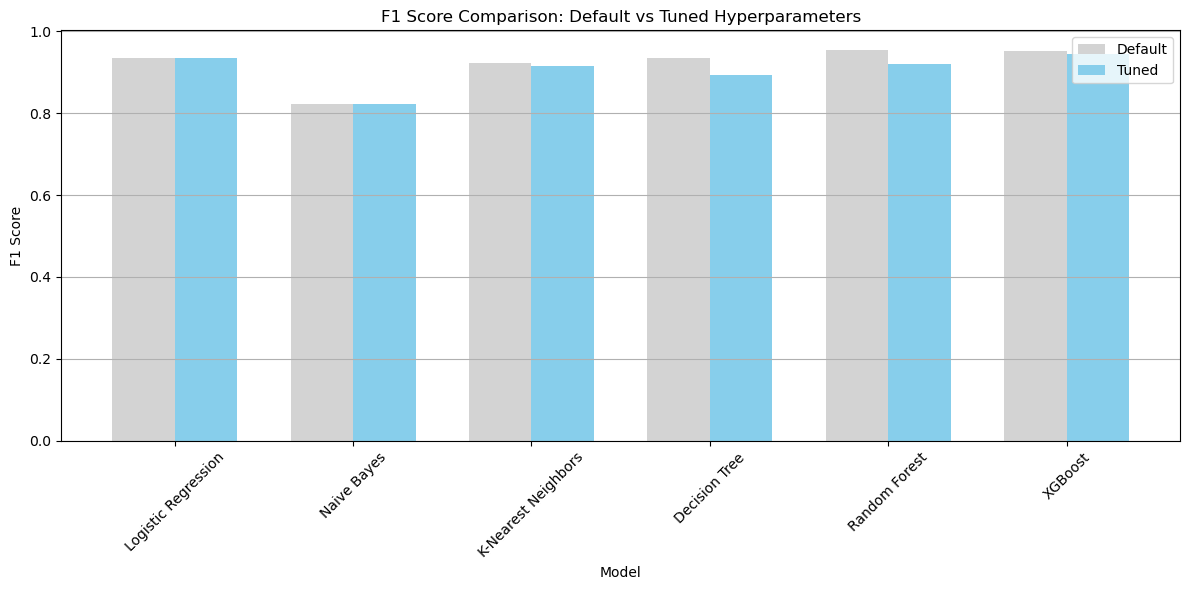

In [71]:
from sklearn.metrics import f1_score
from sklearn.linear_model import LogisticRegression
from sklearn.naive_bayes import GaussianNB
from sklearn.neighbors import KNeighborsClassifier
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
from xgboost import XGBClassifier
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

# Store F1 results
f1_default = {}
f1_tuned = {}

# 1. Logistic Regression
model = LogisticRegression(random_state=42)
model.fit(X_train_scaled, y_train)
f1_default['Logistic Regression'] = f1_score(y_test, model.predict(X_test_scaled))

model_tuned = LogisticRegression(C=0.5, solver='liblinear', random_state=42)
model_tuned.fit(X_train_scaled, y_train)
f1_tuned['Logistic Regression'] = f1_score(y_test, model_tuned.predict(X_test_scaled))

# 2. Naive Bayes
model = GaussianNB()
model.fit(X_train_scaled, y_train)
f1_default['Naive Bayes'] = f1_score(y_test, model.predict(X_test_scaled))
f1_tuned['Naive Bayes'] = f1_default['Naive Bayes']  # No tuning available

# 3. K-Nearest Neighbors
model = KNeighborsClassifier()
model.fit(X_train_scaled, y_train)
f1_default['K-Nearest Neighbors'] = f1_score(y_test, model.predict(X_test_scaled))

model_tuned = KNeighborsClassifier(n_neighbors=7)
model_tuned.fit(X_train_scaled, y_train)
f1_tuned['K-Nearest Neighbors'] = f1_score(y_test, model_tuned.predict(X_test_scaled))

# 4. Decision Tree
model = DecisionTreeClassifier(random_state=42)
model.fit(X_train_scaled, y_train)
f1_default['Decision Tree'] = f1_score(y_test, model.predict(X_test_scaled))

model_tuned = DecisionTreeClassifier(max_depth=5, min_samples_split=10, min_samples_leaf=5, random_state=42)
model_tuned.fit(X_train_scaled, y_train)
f1_tuned['Decision Tree'] = f1_score(y_test, model_tuned.predict(X_test_scaled))

# 5. Random Forest
model = RandomForestClassifier(random_state=42)
model.fit(X_train_scaled, y_train)
f1_default['Random Forest'] = f1_score(y_test, model.predict(X_test_scaled))

model_tuned = RandomForestClassifier(n_estimators=100, max_depth=7, min_samples_split=10,
                                     min_samples_leaf=5, max_features='sqrt', random_state=42)
model_tuned.fit(X_train_scaled, y_train)
f1_tuned['Random Forest'] = f1_score(y_test, model_tuned.predict(X_test_scaled))

# 6. XGBoost
model = XGBClassifier(use_label_encoder=False, eval_metric='logloss', random_state=42)
model.fit(X_train_scaled, y_train)
f1_default['XGBoost'] = f1_score(y_test, model.predict(X_test_scaled))

model_tuned = XGBClassifier(use_label_encoder=False, eval_metric='logloss',
                             max_depth=5, learning_rate=0.1, n_estimators=100,
                             subsample=0.8, colsample_bytree=0.8, gamma=1,
                             reg_alpha=0.5, reg_lambda=1.0, random_state=42)
model_tuned.fit(X_train_scaled, y_train)
f1_tuned['XGBoost'] = f1_score(y_test, model_tuned.predict(X_test_scaled))

# Create DataFrame to compare
comparison_df = pd.DataFrame({
    'Model': list(f1_default.keys()),
    'F1 Score (Default)': list(f1_default.values()),
    'F1 Score (Tuned)': list(f1_tuned.values())
})

# Display comparison
display(comparison_df)

# Plot
plt.figure(figsize=(12, 6))
bar_width = 0.35
x = np.arange(len(comparison_df))

plt.bar(x, comparison_df['F1 Score (Default)'], width=bar_width, label='Default', color='lightgray')
plt.bar(x + bar_width, comparison_df['F1 Score (Tuned)'], width=bar_width, label='Tuned', color='skyblue')

plt.xlabel('Model')
plt.ylabel('F1 Score')
plt.title('F1 Score Comparison: Default vs Tuned Hyperparameters')
plt.xticks(x + bar_width / 2, comparison_df['Model'], rotation=45)
plt.legend()
plt.grid(axis='y')
plt.tight_layout()
plt.show()

## Model Comparison Summary Table

In [75]:
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score
import pandas as pd

# Create a dictionary to hold model names and instances
models = {
    'Logistic Regression': lr_model,
    'Naive Bayes': nb_model,
    'K-Nearest Neighbors': knn_model,
    'Decision Tree': dt_model,
    'Random Forest': rf_model,
    'XGBoost': xgb_model
}

# Initialize list to collect metrics
model_metrics = []

# Loop through each model
for name, model in models.items():
    y_pred = model.predict(X_test_scaled)
    
    acc = accuracy_score(y_test, y_pred)
    prec = precision_score(y_test, y_pred)
    rec = recall_score(y_test, y_pred)
    f1 = f1_score(y_test, y_pred)
    
    model_metrics.append({
        'Model': name,
        'Accuracy': round(acc, 4),
        'Precision': round(prec, 4),
        'Recall': round(rec, 4),
        'F1 Score': round(f1, 4)
    })

# Create and display as a DataFrame
comparison_df = pd.DataFrame(model_metrics)
comparison_df = comparison_df.sort_values(by='F1 Score', ascending=False)

display(comparison_df)


,Model,Accuracy,Precision,Recall,F1 Score
5,XGBoost,0.9435,0.9327,0.9559,0.9441
0,Logistic Regression,0.9354,0.9424,0.9274,0.9349
2,K-Nearest Neighbors,0.9252,0.9386,0.9100,0.9241
4,Random Forest,0.9163,0.8806,0.9632,0.9200
3,Decision Tree,0.8904,0.8720,0.9151,0.8930
1,Naive Bayes,0.8129,0.7797,0.8723,0.8234


## Conclusion 

Based on the evaluation metrics — Accuracy, Precision, Recall, and F1 Score — the XGBoost model outperformed all other models.

- XGBoost achieved the highest F1 Score of 0.9441, indicating strong overall balance between precision and recall.

- Logistic Regression also performed well, closely following XGBoost with an F1 Score of 0.9349.

- K-Nearest Neighbors and Random Forest showed competitive results but were slightly lower.

- Naive Bayes had the lowest overall performance among the models.

Thus, XGBoost is the best-performing model for predicting term deposit subscriptions in this project.